# K-Means Clustering – Danielle Notebook

## 📘 Objective
In this notebook, you will:
- Understand the theory behind K-means clustering
- Implement K-means step by step
- Apply it to real data
- Evaluate your clustering results
- Compare your implementation with scikit-learn’s

## 1️⃣ Introduction to Clustering
### 1.1 What is Clustering?
Clustering is an **unsupervised learning** technique used to group similar data points together. It’s used in:
- Customer segmentation
- Document classification
- Image compression
- Anomaly detection

### 1.2 What is K-means?
K-means is a partitioning algorithm that:
- Divides data into **K clusters**
- Minimizes **intra-cluster variance** (inertia)
- Assumes clusters are spherical and similarly sized

## 2️⃣ K-Means Algorithm – Intuition
### Step-by-step procedure:
1. Randomly initialize K centroids
2. Assign each data point to the nearest centroid
3. Recalculate centroids as the mean of assigned points
4. Repeat steps 2–3 until convergence

Convergence criteria:
- No change in cluster assignments
- Or centroids stop moving

## 3️⃣ Hands-On: Simulated Dataset
### 3.1 Dataset
We’ll use the [custommer segmentation](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/data) dataset from kaggle.

In [292]:
from scipy.spatial.distance import cdist
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Dataset 

The dataset used is the *Mall Customer Segmentation Data*, containing 200 samples and the following features:

- Customer ID (ignored for clustering)
- Gender (encoded numerically)
- Age
- Annual Income (k$)
- Spending Score (1–100)

The key goal is to segment customers based on their income and spending behavior for potential marketing strategies.


In [211]:
data = pd.read_csv('Mall_Customers.csv.xls', index_col= 'CustomerID')
data.head(5)

,Gender,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,,,,
1,Male,19,15,39
2,Male,21,15,81
3,Female,20,16,6
4,Female,23,16,77
5,Female,31,17,40


In [212]:
df = data.copy()
# Encode the gender variable
df['Gender'] = df['Gender'].map({'Male':0, 'Female':1})

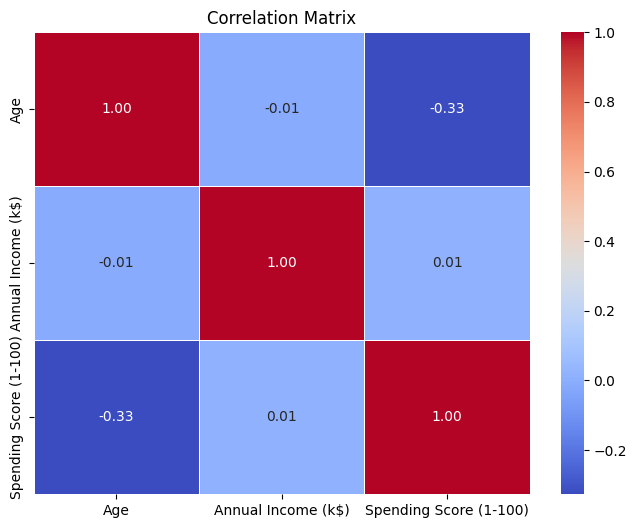

In [213]:
# Compute the correlation matrix
corr_matrix = df[['Age','Annual Income (k$)', 'Spending Score (1-100)' ]].corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

The correlation matrix shows the linear relationships between the numerical variables in the dataset:

- *Age* and *Spending Score*: There is a moderate negative correlation (-0.33), suggesting that younger customers tend to have higher spending scores, while older customers tend to have lower scores.
- *Annual Income* and other variables: There is almost no correlation between annual income and either age (-0.01) or spending score (0.01), indicating that income does not linearly influence spending behavior in this dataset.

In [ ]:
# selected features 
X = df[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Standardize only numeric features

scaler = StandardScaler()
numeric_scaled = scaler.fit_transform(df[['Age','Annual Income (k$)', 'Spending Score (1-100)' ]])

# Concatenate gender with scaled numeric features
X_scale = np.hstack((df[['Gender']].values, numeric_scaled))

### 4.1 Initialize Centroids

In [215]:
def initialize_centroids(X, k):
    """
    Randomly select k points from X as initial centroids.
    """
    indices = np.random.choice(X.shape[0], k, replace = False)
    return X[indices]

### 4.2 Assign Clusters

In [216]:
def assign_clusters(X, centroids):
    """
    Assign each data point to the nearest centroid.
    Returns a vector of cluster labels.
    """
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    return np.argmin(distances, axis=1)

### 4.3 Update Centroids

In [217]:
def compute_centroids(X, labels, k):
    """
    Compute new centroids as the mean of assigned points for each cluster.
    """
    return np.array([X[labels == i].mean(axis=0) for i in range(k)])

def has_converged(old_centroids, new_centroids, tol = 1e-4):
    return np.all(np.linalg.norm(old_centroids - new_centroids, axis = 1) < tol)

### 4.4 Full K-Means Algorithm

In [218]:
def k_means(X, k, max_iters=100):
    """
    Run the full K-means algorithm.
    Returns final centroids and cluster assignments.
    """
    centroids = initialize_centroids(X, k)

    for i in range(max_iters):
        labels = assign_clusters(X, centroids)
        new_centroids = compute_centroids(X, labels, k)

        if has_converged (centroids, new_centroids):
            break 
        centroids = new_centroids

    return labels, centroids, i+1

In [301]:
# Let us put all this in class so it will be easy to use and make all the control
class myKMeans:
    def __init__(self, n_clusters, max_iters=100, tol=1e-4, random_state=None):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.tol = tol
        self.random_state = random_state
        
        self.cluster_centers_ = None
        self.labels_ = None
        self.n_iter_ = 0

# initiliazation function
    def initialize_centroids(self, X):
        if self.random_state is not None:
            np.random.seed(self.random_state)
        indices = np.random.choice(X.shape[0], self.n_clusters, replace=False)
        return X[indices]

#assign point to the nearest cluster
    def assign_clusters(self, X, centroids):
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
        return np.argmin(distances, axis=1)

# update the centroids
    def compute_centroids(self, X, labels):
        return np.array([X[labels == i].mean(axis=0) for i in range(self.n_clusters)])
    
#checking the convergence
    def has_converged(self, old_centroids, new_centroids):
        return np.all(np.linalg.norm(old_centroids - new_centroids, axis=1) < self.tol)

#compute the inertia: the total intra-cluster variance.
    def compute_inertia(self, X, labels, centroids):
        distances = np.linalg.norm(X - centroids[labels], axis=1) ** 2
        return distances.sum()

#train part 
    def fit(self, X):
        centroids = self.initialize_centroids(X)
        for i in range(self.max_iters):
            labels = self.assign_clusters(X, centroids)
            new_centroids = self.compute_centroids(X, labels)
            if self.has_converged(centroids, new_centroids):
                break
            centroids = new_centroids

        self.cluster_centers_ = centroids
        self.labels_ = self.assign_clusters(X, centroids)
        self.n_iter_ = i + 1
        self.inertia_ = self.compute_inertia(X, self.labels_, centroids)  # inertia recorded here
        return self

#prediction 
    def predict(self, X):
        if self.cluster_centers_ is None:
            raise Exception("Fit the model before prediction.")
        return self.assign_clusters(X, self.cluster_centers_)

Training the k_means model  with only Annual Income and Spending Score give very separate classe

Number of iterations: 7
Silhouette: 0.4081809813145816
Inertia: 141.2372331345211


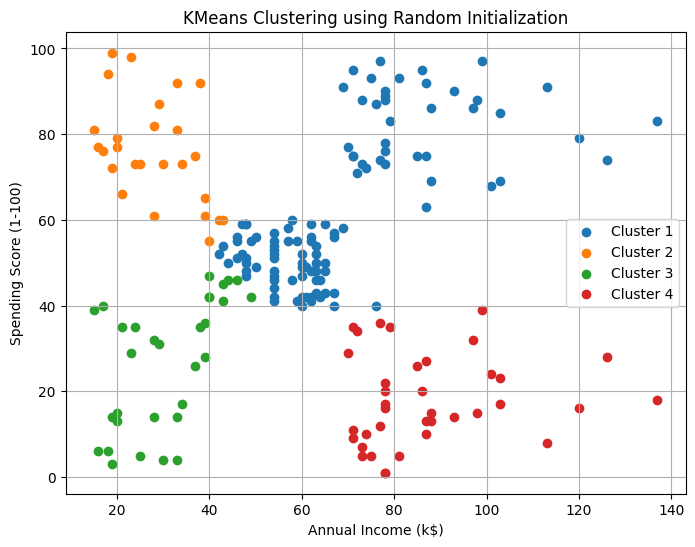

In [291]:
## implement kmeans++ on data with Annual Income and Spending Score only
k=4
kmeans = myKMeans(n_clusters=k, random_state=42)
kmeans.fit(X_scale[:,-2:])
df['Cluster'] = kmeans.labels_
#print("Centroids:\n", kmeans.cluster_centers_)
print("Number of iterations:", kmeans.n_iter_)
print("Silhouette:", silhouette_score(X_scale[:,-2:], kmeans.labels_))
print("Inertia:", kmeans.inertia_)

plt.figure(figsize=(8, 6))
for i in range(kmeans.n_clusters):
    cluster_points = df[df['Cluster'] == i]
    plt.scatter(cluster_points['Annual Income (k$)'],
                cluster_points['Spending Score (1-100)'],
                label=f'Cluster {i+1}')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('KMeans Clustering using Random Initialization')
plt.legend()
plt.grid(True)
plt.show()

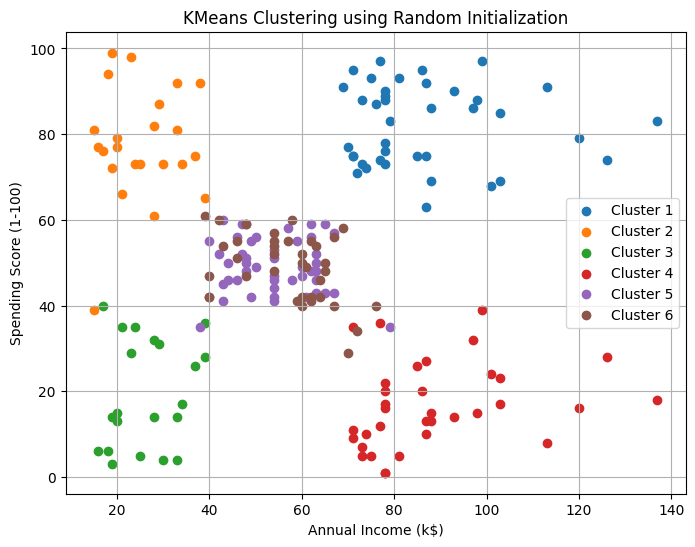

In [ ]:
k=6
kmeans = myKMeans(n_clusters=k, random_state=42)
kmeans.fit(X_scale)
df['Cluster'] = kmeans.labels_
print("Centroids:\n", kmeans.cluster_centers_)
print("Number of iterations:", kmeans.n_iter_)

plt.figure(figsize=(8, 6))
for i in range(kmeans.n_clusters):
    cluster_points = df[df['Cluster'] == i]
    plt.scatter(cluster_points['Annual Income (k$)'],
                cluster_points['Spending Score (1-100)'],
                label=f'Cluster {i+1}')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('KMeans Clustering using Random Initialization')
plt.legend()
plt.grid(True)
plt.show()

Centroids:
 [[ 0.36363636  1.79188376 -0.27815104 -0.02717509]
 [ 0.53846154 -0.44191719  0.99158305  1.23950275]
 [ 0.6         0.5310735  -1.2905084  -1.23646671]
 [ 0.45945946  0.08059205  1.01745256 -1.24270964]
 [ 0.59615385 -1.00776994 -0.76641278  0.48795716]
 [ 0.76666667  0.55379962 -0.15115094 -0.08023123]]
Number of iterations: 5


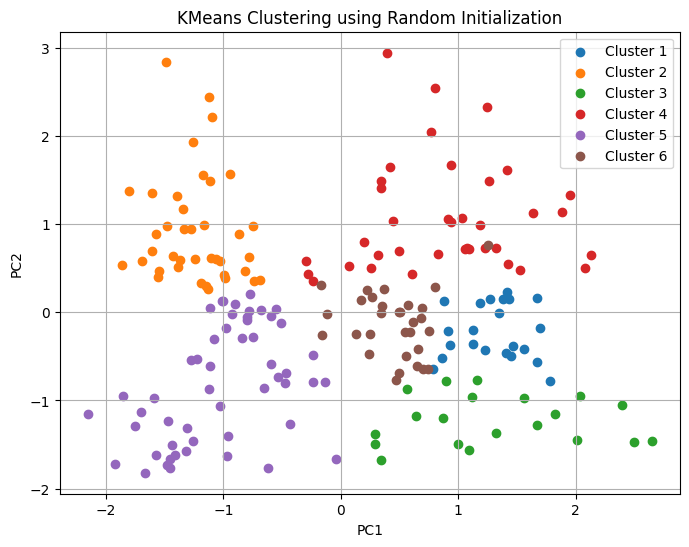

In [335]:
##PCA with Kmeans
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scale[:, 1:])

k=6
kmeans = myKMeans(n_clusters=k, random_state=42)
kmeans.fit(X_scale)
df['Cluster'] = kmeans.labels_
print("Centroids:\n", kmeans.cluster_centers_)
print("Number of iterations:", kmeans.n_iter_)

plt.figure(figsize=(8, 6))
for i in range(kmeans.n_clusters):
    cluster_points = X_pca[df['Cluster'] == i]
    plt.scatter(cluster_points[:,0],
                cluster_points[:,1],
                label=f'Cluster {i+1}')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('KMeans Clustering using Random Initialization')
plt.legend()
plt.grid(True)
plt.show()

### 5.1 Inertia

In [237]:
def compute_inertia(X, centroids, labels):
    """
    Compute total intra-cluster variance (inertia).
    """
    inertia = 0.0
    for i in range(len(X)):
        centroid = centroids[labels[i]]
        diff = X[i] - centroid
        inertia += np.dot(diff, diff)  # squared Euclidean distance
    return inertia

## 5️⃣ Evaluation
### 5.2 Silhouette Score
How similar a point is to its cluster compared to other clusters (optional using `sklearn`).

In [325]:
# X_cale is our data array, labels is the cluster assignments
mykmeans = KMeans(n_clusters=4, random_state=42)
mykmeans.fit(X_scale)
score = silhouette_score(X_scale, mykmeans.labels_)
scorepca = silhouette_score(X_pca, kmeans.labels_)

print("Silhouette Score:", score)
print("Silhouette Score with pca:", scorepca)

Silhouette Score: 0.35044061449694197
Silhouette Score with pca: 0.35059299766220187


## 6️⃣ Comparison with scikit-learn
Use `sklearn.cluster.KMeans` to compare your results:
- Cluster centers
- Inertia
- Assignments

In [ ]:
# X_scale is our data and k is the number of clusters
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X_scale)
mykmeans = myKMeans(n_clusters=4, random_state=42)
mykmeans.fit(X_scale)

#  inertia
print("Inertia:", kmeans.inertia_)
print('Inertia From scratch', mykmeans.inertia_)

#  silhouette
print('-------------------------------------------')
print('Silhouette Kmeans',silhouette_score(X_scale, kmeans.labels_))
print('Silhouette From Scratch',silhouette_score(X_scale, mykmeans.labels_) )

# cluster centers
print('-------------------------------------------')
print('Clusters centers Kmeans',kmeans.cluster_centers_)
print('Clusters From Scratch',mykmeans.cluster_centers_)


print('-------------------------------------------')
center_distances = cdist(kmeans.cluster_centers_, kmeans.cluster_centers_)
print("\nPairwise distances between your centers and sklearn centers:\n", center_distances)


Inertia: 254.36171423484495
Inertia From scratch 254.40989633765145
-------------------------------------------
Silhouette Kmeans 0.35044061449694197
Silhouette From Scratch 0.35125688013667683
-------------------------------------------
Clusters centers Kmeans [[ 0.578125    1.08053722 -0.50445672 -0.37960207]
 [ 0.55       -0.42880597  0.97484722  1.21608539]
 [ 0.59649123 -0.96249203 -0.78476346  0.39202966]
 [ 0.48717949  0.07333084  0.97494509 -1.19729675]]
Clusters From Scratch [[ 0.55       -0.42880597  0.97484722  1.21608539]
 [ 0.59649123 -0.96249203 -0.78476346  0.39202966]
 [ 0.58461538  1.06297508 -0.4946758  -0.37865953]
 [ 0.47368421  0.0768659   0.9971462  -1.22042727]]
-------------------------------------------

Pairwise distances between your centers and sklearn centers:
 [[0.         2.64829502 2.20188402 1.96976904]
 [2.64829502 0.         2.01550983 2.46586722]
 [2.20188402 2.01550983 0.         2.58986693]
 [1.96976904 2.46586722 2.58986693 0.        ]]


## 7️⃣ Experiments
### 7.1 Multiple Initializations
Try running K-means multiple times to observe different results due to random initialization.

In [242]:
# Number of trials
n_trials = 10
k = 5

inertias = []
silhouettes = []
centers_list = []

for i in range(n_trials):
    kmeans = myKMeans(n_clusters=k, random_state=i)  # Change seed each time
    kmeans.fit(X_scale)

    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scale, kmeans.labels_))
    centers_list.append(kmeans.cluster_centers_)

# Print results
for i in range(n_trials):
    print(f"Run {i+1}: Inertia = {inertias[i]:.2f}, Silhouette = {silhouettes[i]:.4f}")

Run 1: Inertia = 217.22, Silhouette = 0.3554
Run 2: Inertia = 287.99, Silhouette = 0.2539
Run 3: Inertia = 244.16, Silhouette = 0.3089
Run 4: Inertia = 243.60, Silhouette = 0.2929
Run 5: Inertia = 240.12, Silhouette = 0.3087
Run 6: Inertia = 218.90, Silhouette = 0.3473
Run 7: Inertia = 216.78, Silhouette = 0.3498
Run 8: Inertia = 217.22, Silhouette = 0.3554
Run 9: Inertia = 216.78, Silhouette = 0.3498
Run 10: Inertia = 217.22, Silhouette = 0.3554


### 7.2 Elbow Method
Plot inertia vs. K to find the optimal number of clusters.

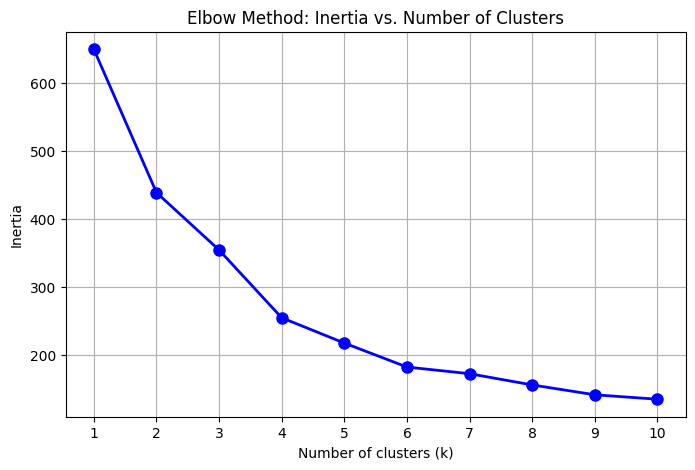

In [244]:
inertias = []
k_values = range(1, 11)  # Check k=1 to k=10

for k in k_values:
    kmeans = myKMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scale)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_values, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method: Inertia vs. Number of Clusters')
plt.xticks(k_values)
plt.grid(True)
plt.show()


## 8️⃣ Bonus Challenges
- Implement a **convergence check** based on centroid movement.
- Apply K-means to **image compression** (reshape image pixels).
- Try **PCA before clustering** to reduce dimensionality.
- Implement **K-means++ initialization**.

In [326]:
class myKMeans:
    def __init__(self, n_clusters, max_iters=100, tol=1e-4, random_state=None, init_method='kmeans++'):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.tol = tol
        self.random_state = random_state
        self.init_method = init_method

        self.cluster_centers_ = None
        self.labels_ = None
        self.n_iter_ = 0
        self.inertia_ = None

    def initialize_centroids(self, X):
        if self.random_state is not None:
            np.random.seed(self.random_state)

        n_samples, _ = X.shape

        if self.init_method == 'kmeans++':
            centroids = []
            first_index = np.random.randint(n_samples)
            centroids.append(X[first_index])

            for _ in range(1, self.n_clusters):
                distances = np.min([np.linalg.norm(X - c, axis=1) ** 2 for c in centroids], axis=0)
                probs = distances / np.sum(distances)
                next_index = np.random.choice(n_samples, p=probs)
                centroids.append(X[next_index])

            return np.array(centroids)

        elif self.init_method == 'max_distance':
            centroids = []
            first_idx = np.random.randint(n_samples)
            centroids.append(X[first_idx])

            for _ in range(1, self.n_clusters):
                distances = np.array([
                    min(np.linalg.norm(x - c)**2 for c in centroids)
                    for x in X
                ])
                next_centroid = X[np.argmax(distances)]
                centroids.append(next_centroid)

            return np.array(centroids)

        elif self.init_method == 'random':
            indices = np.random.choice(X.shape[0], self.n_clusters, replace=False)
            return X[indices]

        else:
            raise ValueError("Unknown init_method. Choose from 'kmeans++', 'max_distance', or 'random'.")

    def assign_clusters(self, X, centroids):
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
        return np.argmin(distances, axis=1)

    def compute_centroids(self, X, labels):
        return np.array([X[labels == i].mean(axis=0) for i in range(self.n_clusters)])

    def has_converged(self, old_centroids, new_centroids):
        return np.all(np.linalg.norm(old_centroids - new_centroids, axis=1) < self.tol)

    def compute_inertia(self, X, labels, centroids):
        distances = np.linalg.norm(X - centroids[labels], axis=1) ** 2
        return distances.sum()

    def fit(self, X):
        centroids = self.initialize_centroids(X)
        for i in range(self.max_iters):
            labels = self.assign_clusters(X, centroids)
            new_centroids = self.compute_centroids(X, labels)
            if self.has_converged(centroids, new_centroids):
                break
            centroids = new_centroids

        self.cluster_centers_ = centroids
        self.labels_ = self.assign_clusters(X, centroids)
        self.n_iter_ = i + 1
        self.inertia_ = self.compute_inertia(X, self.labels_, centroids)
        return self

    def predict(self, X):
        if self.cluster_centers_ is None:
            raise Exception("Fit the model before prediction.")
        return self.assign_clusters(X, self.cluster_centers_)


Number of iterations: 5
Silhouette: 0.42092860310837993
Inertia: 122.90870365241918


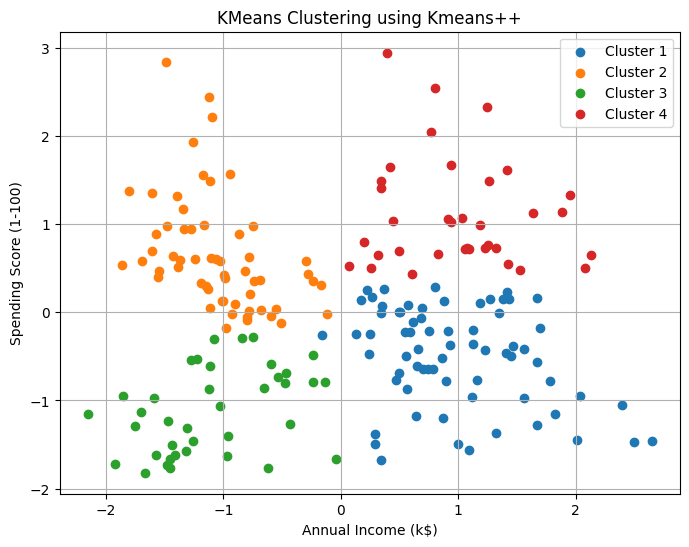

In [332]:
## implement kmeans++ on data with Annual Income and Spending Score only
k=4
kmeans = myKMeans(n_clusters=k, random_state=42, init_method='kmeans++')
kmeans.fit(X_pca)
df['Cluster'] = kmeans.labels_
#print("Centroids:\n", kmeans.cluster_centers_)
print("Number of iterations:", kmeans.n_iter_)
print("Silhouette:", silhouette_score(X_pca, kmeans.labels_))
print("Inertia:", kmeans.inertia_)

plt.figure(figsize=(8, 6))
for i in range(kmeans.n_clusters):
    cluster_points = X_pca[df['Cluster'] == i]
    plt.scatter(cluster_points[:,0],
                cluster_points[:,1],
                label=f'Cluster {i+1}')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('KMeans Clustering using Kmeans++')
plt.legend()
plt.grid(True)
plt.show()

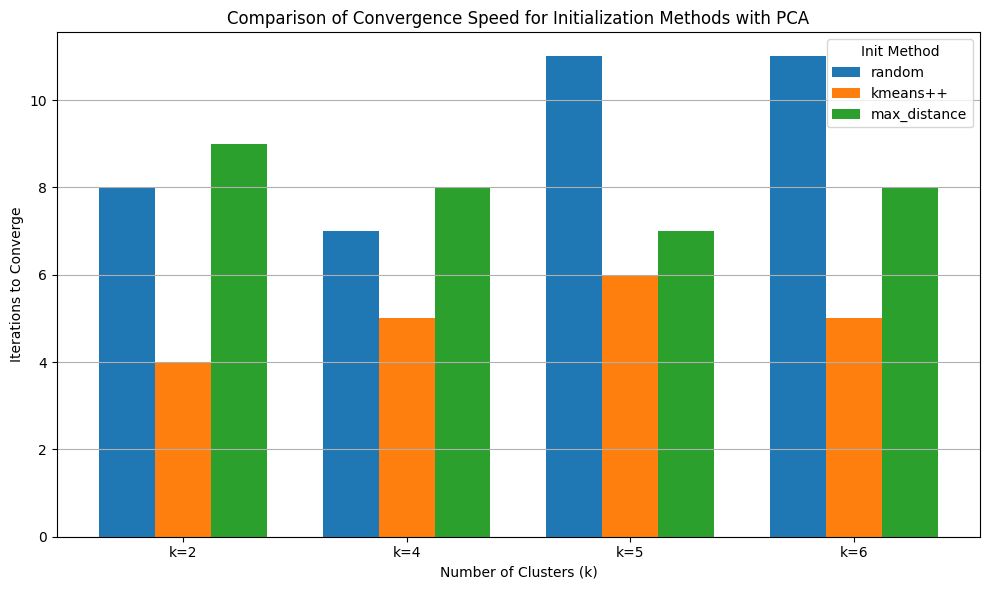

{'random': [8, 7, 11, 11], 'kmeans++': [4, 5, 6, 5], 'max_distance': [9, 8, 7, 8]}


In [333]:

methods = ['random', 'kmeans++', 'max_distance']
k_values = [2,4, 5, 6]  # different k
results = {method: [] for method in methods}

for k in k_values:
    for method in methods:
        model = myKMeans(n_clusters=k, init_method=method, random_state=42)
        model.fit(X_pca)
        results[method].append(model.n_iter_)

# 🔧 Plotting grouped bars
x = np.arange(len(k_values))  # X locations for groups
width = 0.25

plt.figure(figsize=(10, 6))

for i, method in enumerate(methods):
    plt.bar(x + i * width, results[method], width=width, label=method)

plt.xticks(x + width, [f'k={k}' for k in k_values])
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Iterations to Converge")
plt.title("Comparison of Convergence Speed for Initialization Methods with PCA")
plt.legend(title="Init Method")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

print(results)


The experiment shows that initialization significantly affects the K-Means performance:

- K-Means++ provided the best performance, converging in fewer iterations and yielding well-separated clusters.
- Max-Distance Seeding method is not well improved over random initialization.
- The Elbow Method was effective in identifying a suitable value for $ k $.

Cluster quality can also be measured using metrics like silhouette score or Davies–Bouldin index (for future work).

## 9️⃣ Conceptual Quiz (Optional)
1. What is the objective function optimized in K-means?
2. Why can initialization affect the result?
3. How can we choose K without labels?
4. When does K-means fail?

_End of Notebook_


### K-means Clustering: Key Questions & Answers

#### 1. What is the objective function optimized in K-means?

**K-means minimizes the *inertia* (within-cluster sum of squares):**

$$
\text{Inertia} = \sum_{i=1}^{n} \| x_i - \mu_{z_i} \|^2
$$

Where:
- $ x_i $: a data point
- $ \mu_{z_i} $: the centroid of the assigned cluster
- $\| \cdot \|^2 $: squared Euclidean distance

**Goal:** Minimize the total distance from points to their assigned cluster centers.

---

#### 2. Why can initialization affect the result?

**K-means uses random starting centroids**, and the algorithm converges to **local minima**.

- **Bad initialization** → poor clustering (wrong groups, higher inertia)
- **Good initialization** (e.g., `kmeans++`) → faster and better convergence

---

#### 3. How can we choose K without labels?

we can use unsupervised **model selection techniques** by using different technique. For example:

**Elbow Method** using plot of the  **inertia vs. K** and we will looking for the "elbow" point where the curve flattens.

**Silhouette Score**: it measures how well-separated and cohesive the clusters are. Score ranges from **-1 (poor)** to **+1 (ideal)**.

**Gap Statistic**: using to compares inertia with expected inertia from random data.

---

#### 4. When does K-means fail?

K-means may fail or give poor results when the data violates its assumptions:

| Limitation           | Why It Fails                                |
|------------------------|-----------------------------------------------|
| Non-spherical clusters | K-means assumes round clusters                |
| Varying cluster sizes  | It treats all clusters as equally sized       |
| Varying densities      | Sparse vs. dense clusters confuse the model   |
| Outliers               | Sensitive to outliers, which can shift centroids |
| Wrong K                | A poor K gives incorrect or weak clustering   |

---
